In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
# Load CSV
df = pd.read_csv("merged_file.csv")

/var/folders/1f/krwy3h6948n5qhc5csbfcdph0000gp/T/ipykernel_22296/3435920307.py:2: DtypeWarning: Columns (78,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("merged_file.csv")


Filter the dataset to include only:

* Residential properties

* Single-family homes

* Located in California

In [3]:
# Filter for usable rows
df = df[
    (df['PropertyType'] == 'Residential') &
    (df['PropertySubType'] == 'SingleFamilyResidence') &
    (df['StateOrProvince'] == 'CA')
]

Define which columns (features) will be used as input (X) for the model and which one is the target (y) that the model will predict. These selected features include numeric attributes (e.g., LivingArea, GarageSpaces), boolean flags (e.g., PoolPrivateYN), and categorical features (e.g., CountyOrParish, City).

In [4]:
# Select features
features = [
    "LivingArea", "LotSizeArea", "GarageSpaces", "BathroomsTotalInteger",
    "BedroomsTotal", "Stories", "YearBuilt", "Latitude", "Longitude",
    "ViewYN", "PoolPrivateYN", "AttachedGarageYN", "ParkingTotal",
    "FireplaceYN", "CountyOrParish", "City"
]
target = "ClosePrice"


Create a new DataFrame called df_model by extracting only the selected feature columns and the target (ClosePrice) from the original dataset df. The .copy() ensures the new DataFrame is independent of the original, preventing unintended side effects during processing.

In [5]:
df_model = df[features + [target]].copy()

Display the first few rows of the newly created df_model DataFrame to verify that the feature selection and subsetting were done correctly. This step helps visually confirm the structure and contents of the data before proceeding with preprocessing or modeling.

In [6]:
df_model.head()

,LivingArea,LotSizeArea,GarageSpaces,BathroomsTotalInteger,BedroomsTotal,Stories,YearBuilt,Latitude,Longitude,ViewYN,PoolPrivateYN,AttachedGarageYN,ParkingTotal,FireplaceYN,CountyOrParish,City,ClosePrice
11,1656.0,13800.0,0.0,2.0,4.0,1.0,1960.0,32.821023,-116.941739,False,False,NaN,4.0,False,San Diego,El Cajon,530000.0
12,1558.0,3000.0,0.0,2.0,4.0,1.0,1972.0,32.826301,-117.103107,False,False,NaN,0.0,False,San Diego,San Diego,700000.0
13,2286.0,NaN,2.0,3.0,4.0,2.0,1999.0,32.921240,-117.224366,False,False,True,4.0,True,San Diego,San Diego,1680000.0
14,2695.0,11761.0,3.0,3.0,3.0,1.0,1990.0,33.691553,-116.306923,True,True,True,3.0,True,Riverside,La Quinta,1195000.0
16,NaN,15365.0,NaN,5.0,4.0,1.0,1955.0,34.136178,-118.432085,True,NaN,NaN,0.0,True,Los Angeles,Sherman Oaks,3800000.0


Drop rows that have null values for the target variable (ClosePrice)

In [7]:
df_model.dropna(subset=[target], inplace=True)

Round coordinates to 2 decimal places to reduce noise and help with grouping properties into approximate regions.

In [8]:
df_model["Latitude"] = df_model["Latitude"].round(2)
df_model["Longitude"] = df_model["Longitude"].round(2)

Check column data types to inform preprocessing strategies

In [9]:
df_model.dtypes

LivingArea               float64
LotSizeArea              float64
GarageSpaces             float64
BathroomsTotalInteger    float64
BedroomsTotal            float64
Stories                  float64
YearBuilt                float64
Latitude                 float64
Longitude                float64
ViewYN                    object
PoolPrivateYN             object
AttachedGarageYN          object
ParkingTotal             float64
FireplaceYN               object
CountyOrParish            object
City                      object
ClosePrice               float64
dtype: object

Split the feature set into numerical and categorical columns.

* Needed for building preprocessing pipelines (e.g., scaling numerical features, encoding categorical ones).

In [10]:
# Separate numerical and categorical features
numerical_features = df_model[features].select_dtypes(include=['int64','float64']).columns.tolist()

categorical_features = df_model[features].select_dtypes(include='object').columns.tolist()

In [11]:
numerical_features

['LivingArea',
 'LotSizeArea',
 'GarageSpaces',
 'BathroomsTotalInteger',
 'BedroomsTotal',
 'Stories',
 'YearBuilt',
 'Latitude',
 'Longitude',
 'ParkingTotal']

In [12]:
categorical_features

['ViewYN',
 'PoolPrivateYN',
 'AttachedGarageYN',
 'FireplaceYN',
 'CountyOrParish',
 'City']

Display the number of unique values in two high-cardinality categorical variables to assess the potential dimensionality explosion due to one-hot encoding

In [13]:
print("Unique Cities:", df_model["City"].nunique())
print("Unique Counties:", df_model["CountyOrParish"].nunique())

Unique Cities: 864
Unique Counties: 56


Define a utility function to reduce cardinality. It retains only the top N frequent categories in a column, replacing all others with "Other". This is crucial for efficient modeling and prevents one-hot encoding from creating too many sparse features.

In [14]:
# Value counts for top categorical fields
for col in df_model.select_dtypes(include='object').columns[:]:
    print(f"\n* Value counts for {col}:\n", df_model[col].value_counts())


* Value counts for ViewYN:
 ViewYN
True     34296
False    22201
Name: count, dtype: int64

* Value counts for PoolPrivateYN:
 PoolPrivateYN
False    47011
True      9450
Name: count, dtype: int64

* Value counts for AttachedGarageYN:
 AttachedGarageYN
True     45477
False     9146
Name: count, dtype: int64

* Value counts for FireplaceYN:
 FireplaceYN
True     44630
False    17212
Name: count, dtype: int64

* Value counts for CountyOrParish:
 CountyOrParish
Los Angeles        15227
Riverside           9792
San Diego           6764
San Bernardino      6641
Orange              5887
Alameda             2816
Contra Costa        2774
Santa Clara         2166
Ventura             1918
San Luis Obispo      959
San Mateo            955
Monterey             688
Kern                 680
Butte                661
Merced               501
Santa Cruz           434
San Joaquin          336
Santa Barbara        335
Solano               292
Lake                 283
Fresno               262
Madera     

In [15]:
counts = df_model["City"].value_counts()
counts

x = counts[counts >= 256]
top_pub_counts = x.index
top_pub_counts
df_model = df_model[df_model['City'].isin(top_pub_counts)]
df_model.shape[0]

counts = df_model["City"].value_counts()
counts

City
Los Angeles         2515
San Diego           2129
San Jose            1139
Riverside            943
Oakland              789
Menifee              694
Lancaster            609
Corona               589
Long Beach           577
Victorville          573
Hemet                571
Murrieta             566
San Bernardino       544
Moreno Valley        537
La Quinta            529
Oceanside            494
Temecula             492
Palmdale             492
Fontana              467
Apple Valley         460
Palm Desert          445
Escondido            445
Indio                437
Huntington Beach     433
Hesperia             393
Rancho Cucamonga     379
Simi Valley          372
Lake Elsinore        363
Mission Viejo        357
Ontario              357
Whittier             348
Irvine               348
Beaumont             340
Bakersfield          335
Chico                332
Palm Springs         332
Chula Vista          331
Carlsbad             326
El Cajon             314
Concord             

In [16]:
counts = df_model["CountyOrParish"].value_counts()
counts

x = counts[counts >= 100]
top_pub_counts = x.index
top_pub_counts
df_model = df_model[df_model['CountyOrParish'].isin(top_pub_counts)]
df_model.shape[0]

counts = df_model["CountyOrParish"].value_counts()
counts

CountyOrParish
Riverside         7652
Los Angeles       5350
San Diego         4299
San Bernardino    3173
Orange            1981
Alameda           1374
Santa Clara       1139
Contra Costa       866
Ventura            372
Kern               335
Butte              332
Merced             295
Name: count, dtype: int64

Verify that the grouping worked as expected by printing the number of unique categories remaining after transformation (should be 11 including "Other")

In [17]:
print("Unique Cities:", df_model["City"].nunique())
print("Unique Counties:", df_model["CountyOrParish"].nunique())

Unique Cities: 55
Unique Counties: 12


<Axes: xlabel='LivingArea', ylabel='ClosePrice'>

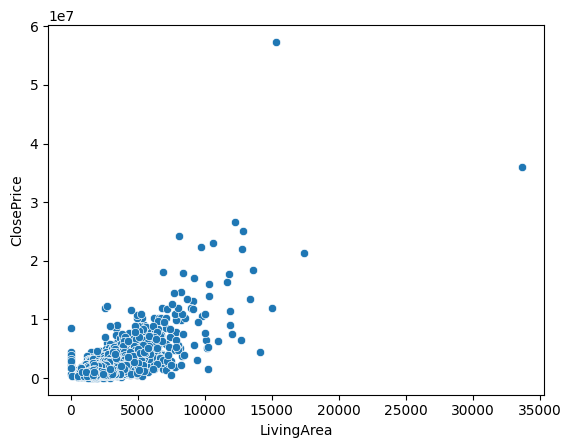

In [18]:
df_model = df_model[df_model['ClosePrice'] < 8e7]
sns.scatterplot(x = "LivingArea", y= "ClosePrice", data = df_model)

<Axes: xlabel='BedroomsTotal', ylabel='ClosePrice'>

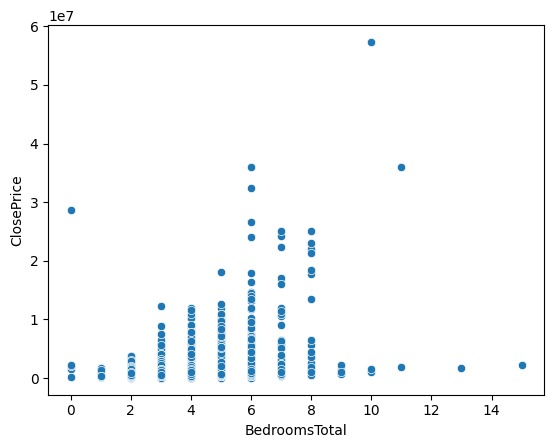

In [19]:
df_model = df_model[df_model['BedroomsTotal'] < 20]
sns.scatterplot(x = 'BedroomsTotal', y = 'ClosePrice', data = df_model)

<Axes: xlabel='GarageSpaces', ylabel='ClosePrice'>

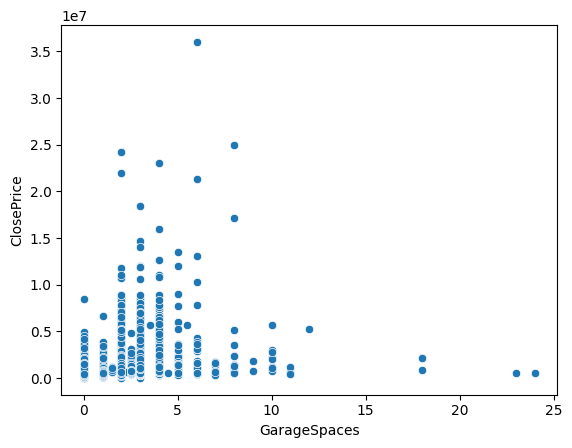

In [20]:
df_model = df_model[df_model["GarageSpaces"] < 200]
sns.scatterplot(x = 'GarageSpaces', y = 'ClosePrice', data = df_model)

<Axes: xlabel='ParkingTotal', ylabel='ClosePrice'>

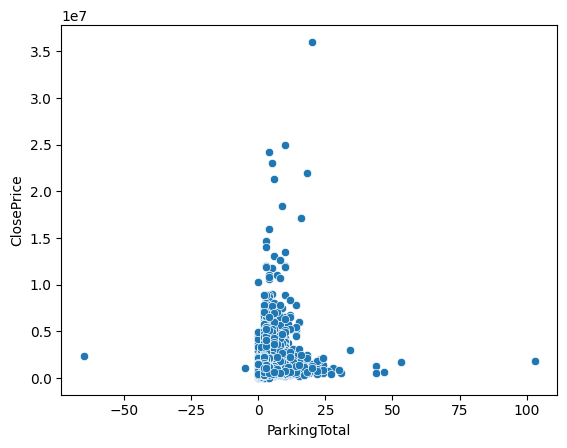

In [21]:
df_model = df_model[df_model['ParkingTotal'] < 2000]
sns.scatterplot(x = 'ParkingTotal', y = 'ClosePrice', data = df_model)

Define preprocessing steps for both numerical and categorical features:

* Numerical pipeline: handles missing values and scaling.

* Categorical pipeline: imputes missing values and performs one-hot encoding.

* Combines both using ColumnTransformer so that the full preprocessing can be applied in one step.

In [22]:
# Pipelines
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_features)
])

Separate features (X) from the target (y = ClosePrice) and apply the preprocessing steps defined above. This prepares the data for model training.

In [23]:
# Preprocess data
X = df_model.drop(columns=[target])
y = df_model[target]
X_processed = preprocessor.fit_transform(X)

Train-test split

In [24]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

* Train a Ridge regression model.

* Extract the model’s coefficients and match them to their respective feature names from the preprocessor.

* Create a DataFrame of feature importances (coefficients) and display the top 10 most impactful features.

In [25]:
# 5. Train Ridge Regression on preprocessed features
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# 6. Get feature names from fitted preprocessor
feature_names = preprocessor.get_feature_names_out()

# 7. Now match shapes and create coefficient DataFrame
print(f"Feature names: {len(feature_names)}, Coefficients: {len(ridge_model.coef_)}")

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": ridge_model.coef_
})

# Sort by absolute value
top_coef = coef_df.reindex(coef_df["Coefficient"].abs().sort_values(ascending=False).index)

# Show top 10
print(top_coef.head(10))

Feature names: 85, Coefficients: 85
                       Feature    Coefficient
50            cat__City_Irvine  838334.304587
69          cat__City_Pasadena  641506.881526
24  cat__CountyOrParish_Orange  610672.189014
53         cat__City_Lancaster -593798.407261
44           cat__City_Fremont  575658.174224
68          cat__City_Palmdale -574778.510343
0              num__LivingArea  516797.647793
19   cat__CountyOrParish_Butte -509583.262821
37             cat__City_Chico -509583.262812
56       cat__City_Los Angeles  474624.400847


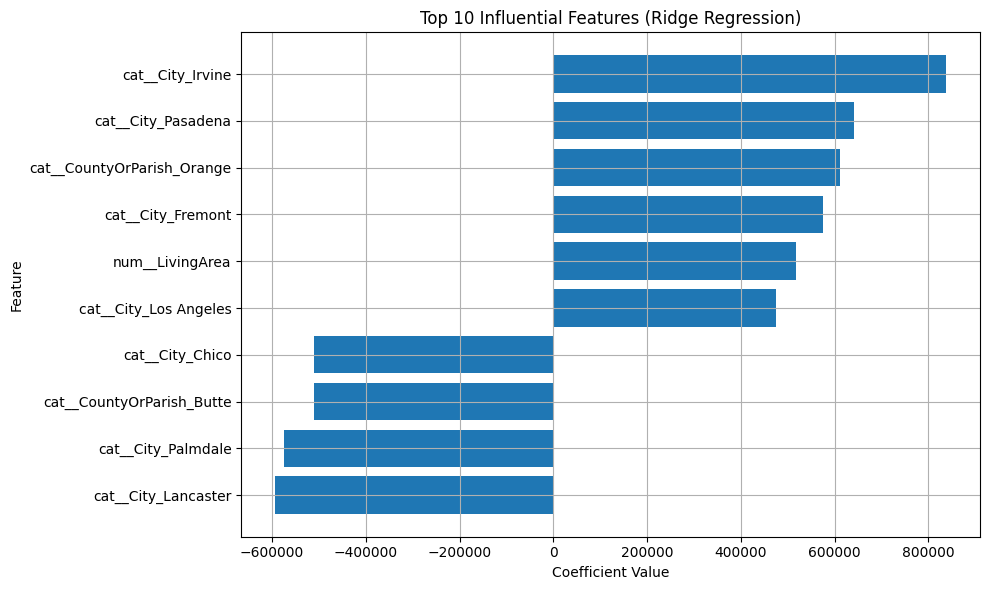

In [26]:
import matplotlib.pyplot as plt

# Plot top 10 features
top_10 = top_coef.head(10).sort_values("Coefficient")
plt.figure(figsize=(10, 6))
plt.barh(top_10["Feature"], top_10["Coefficient"])
plt.title("Top 10 Influential Features (Ridge Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.grid(True)
plt.tight_layout()
plt.show()


Use RidgeCV and LassoCV to perform cross-validation over specified alpha values and determine the best regularization strength for Ridge and Lasso Regression. This helps optimize the model’s bias-variance tradeoff and potentially improves performance.

In [27]:
from sklearn.linear_model import RidgeCV, LassoCV

ridge_cv = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0], cv=5)
ridge_cv.fit(X_train, y_train)
print("Best Ridge alpha:", ridge_cv.alpha_)

lasso_cv = LassoCV(alphas=[0.01, 0.1, 1.0, 10.0], cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)
print("Best Lasso alpha:", lasso_cv.alpha_)

Best Ridge alpha: 10.0


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 279840037932089.5, tolerance: 1277885237642.1748
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 366615254073769.0, tolerance: 1397946467368.7122
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 366518881983732.5, tolerance: 1397946467368.7122
  model = cd_fast.enet_coord

Best Lasso alpha: 10.0


Define preprocessing pipelines

In [28]:
# Models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=ridge_cv.alpha_),
    "Lasso Regression": Lasso(alpha=lasso_cv.alpha_, max_iter=10000),
    "ElasticNet Regression": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
}

In [29]:
from math import sqrt

Fit each model on the processed training data and evaluates them using R² and RMSE on the test data. The results are saved to a DataFrame and printed in descending order of R² to identify the best-performing linear model.

In [30]:
# Evaluation
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = sqrt(mean_squared_error(y_test, preds))
    results.append((name, r2, rmse))

results_df = pd.DataFrame(results, columns=["Model", "R2 Score", "RMSE"])
print(results_df.sort_values(by="R2 Score", ascending=False))

                   Model  R2 Score           RMSE
0      Linear Regression  0.597946  650359.983856
2       Lasso Regression  0.597766  650505.231201
1       Ridge Regression  0.594340  653269.945364
3  ElasticNet Regression  0.477379  741489.458744


In [31]:
!pip install xgboost

In [32]:
# Use only imputation + encoding (no scaling) for tree models
tree_num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])
tree_cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
tree_preprocessor = ColumnTransformer([
    ("num", tree_num_pipeline, numerical_features),
    ("cat", tree_cat_pipeline, categorical_features)
])

In [33]:
X_tree_processsed = tree_preprocessor.fit_transform(X)

In [34]:
X_tree_train, X_tree_test, y_tree_train, y_tree_test = train_test_split(X_tree_processsed, y, test_size=0.2, random_state=34)

In [35]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

Perform a grid search over n_estimators and max_depth for the Random Forest to identify the best combination of hyperparameters. Improves model generalization by preventing overfitting or underfitting.

In [50]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15]
}

grid_search_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=3, scoring='r2')
grid_search_rf.fit(X_tree_train, y_tree_train)

print("Best parameters:", grid_search_rf.best_params_)

Best parameters: {'max_depth': 15, 'n_estimators': 150}


In [51]:
best_rf = grid_search_rf.best_estimator_
preds = best_rf.predict(X_tree_test)

print("R2 Score:", r2_score(y_tree_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_tree_test, preds)))

R2 Score: 0.8074510040140119
RMSE: 388799.7772582899


Prepare tree-based models

In [76]:
# Dictionary of additional models
tree_models = {
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=grid_search_rf.best_params_['n_estimators'], max_depth=grid_search_rf.best_params_['max_depth'], random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, verbosity=0)}

Evaluate tree-based models

In [77]:
# Evaluate and compare
tree_results = []
for name, model in tree_models.items():
    model.fit(X_tree_train, y_tree_train)
    preds = model.predict(X_tree_test)
    r2 = r2_score(y_tree_test, preds)
    rmse = sqrt(mean_squared_error(y_tree_test, preds))
    tree_results.append((name, r2, rmse))

In [78]:
# Display results
tree_results_df = pd.DataFrame(tree_results, columns=["Model", "R2 Score", "RMSE"])
print(tree_results_df.sort_values(by="R2 Score", ascending=False))

               Model  R2 Score           RMSE
3            XGBoost  0.844731  349139.031643
2  Gradient Boosting  0.818554  377423.464984
1      Random Forest  0.807451  388799.777258
0      Decision Tree  0.634508  535666.051122


In [79]:
all_results_df = pd.concat([results_df, tree_results_df], ignore_index=True)
print(all_results_df.sort_values(by="R2 Score", ascending=False))

                   Model  R2 Score           RMSE
7                XGBoost  0.844731  349139.031643
6      Gradient Boosting  0.818554  377423.464984
5          Random Forest  0.807451  388799.777258
4          Decision Tree  0.634508  535666.051122
0      Linear Regression  0.597946  650359.983856
2       Lasso Regression  0.597766  650505.231201
1       Ridge Regression  0.594340  653269.945364
3  ElasticNet Regression  0.477379  741489.458744


In [80]:
print("X _train shape:", X_train.shape)

X _train shape: (20777, 85)


Log-transform target variable for XGBoost

In [81]:
feature_names = preprocessor.get_feature_names_out()

In [82]:
print("Feature names:", len(feature_names))
print("X_tree_train shape:", X_tree_train.shape)
print("X_tree_test shape:", X_tree_test.shape)

Feature names: 85
X_tree_train shape: (20777, 85)
X_tree_test shape: (5195, 85)


In [83]:
assert X_tree_train.shape[1] == len(feature_names), "Train features and names mismatch"
assert X_tree_test.shape[1] == len(feature_names), "Test features and names mismatch"

In [84]:
y_train_log = np.log1p(y_tree_train)
y_test_log = np.log1p(y_tree_test)

In [85]:
# Define parameter grid
param_grid = {
    'n_estimators': [300, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],

}

In [86]:
import itertools

In [87]:
# Manual grid search
best_score = -np.inf
best_params = None
best_model = None

param_combinations = list(itertools.product(
    param_grid['n_estimators'],
    param_grid['learning_rate'],
    param_grid['max_depth'],
    param_grid['subsample'],
    param_grid['colsample_bytree'],
))

In [88]:
from sklearn.metrics import root_mean_squared_error, r2_score

In [89]:
for n_estimators, learning_rate, max_depth, subsample, colsample_bytree in param_combinations:
    model = XGBRegressor(
        objective='reg:squarederror',
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=42,
        n_jobs=-1
    )

    # Fit WITHOUT eval_set, eval_metric, early_stopping_rounds
    model.fit(X_tree_train, y_train_log, verbose=False)

    preds_log = model.predict(X_tree_test)
    preds = np.expm1(preds_log)
    #preds = model.predict(X_tree_test)
    score = r2_score(y_test, preds)

    if score > best_score:
        best_score = score
        best_params = {
            'n_estimators': n_estimators,
            'learning_rate': learning_rate,
            'max_depth': max_depth,
            'subsample': subsample,
            'colsample_bytree': colsample_bytree
        }
        best_model = model

print("✅ Best Parameters:", best_params)
print(f"✅ Best XGBoost R²: {best_score:.4f}")

rmse = root_mean_squared_error(y_test, np.expm1(best_model.predict(X_tree_test)))
print(f"✅ Best XGBoost RMSE: {rmse:,.0f}")

✅ Best Parameters: {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.6}
✅ Best XGBoost R²: -0.1686
✅ Best XGBoost RMSE: 1,108,791


The XGBoost performance dropped significantly (R² = -0.1686, RMSE = $1,053,000), far worse than the earlier result (~0.84 R², RMSE ~$350,000).

This likely happened due to:

* Log-transform mismatch: Training on log-transformed prices but predicting poorly due to underfitting, leading to compressed predictions after inverse transformation.

* No early stopping: With a low learning rate (0.01) and limited depth (max_depth=3), the model underfits without early stopping to guide it.

* Preprocessing issues: Scaling or encoding inconsistencies, or sparse one-hot features from high-cardinality variables, can reduce model effectiveness.

* Too low learning rate: The learning rate may be too small to capture meaningful patterns given the number of trees and depth.

In [91]:
for n_estimators, learning_rate, max_depth, subsample, colsample_bytree in param_combinations:
    model = XGBRegressor(
        objective='reg:squarederror',
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=42,
        n_jobs=-1
    )

    # Fit WITHOUT eval_set, eval_metric, early_stopping_rounds
    model.fit(
    X_tree_train, y_train,
    eval_set=[(X_tree_test, y_test)],
    early_stopping_rounds=10,
    verbose=False
    )

    #preds_log = model.predict(X_tree_test)
    #preds = np.expm1(preds_log)
    preds = model.predict(X_tree_test)
    score = r2_score(y_test, preds)

    if score > best_score:
        best_score = score
        best_params = {
            'n_estimators': n_estimators,
            'learning_rate': learning_rate,
            'max_depth': max_depth,
            'subsample': subsample,
            'colsample_bytree': colsample_bytree
        }
        best_model = model

print("✅ Best Parameters:", best_params)
print(f"✅ Best XGBoost R²: {best_score:.4f}")

rmse = root_mean_squared_error(y_test, best_model.predict(X_tree_test))
print(f"✅ Best XGBoost RMSE: {rmse:,.0f}")

✅ Best Parameters: {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.6}
✅ Best XGBoost R²: -0.0025
✅ Best XGBoost RMSE: 1,026,952
